# Representing geographic data as networks

Contents:

- Basic concepts: nodes, edges, node/edge attributes, topology, connectivity, directionality, what Python tools are out there that can be used?
- How to create a simple graph from scratch
- How to create a graph from a file representing streets
- How to create a routable graph from OpenStreetMap
- Other uses of graphs - morphology, spatial weights, etc.

## Basic concepts

As we briefly introduced in Chapter 5.2, networks are data structures that consists of nodes that are connected to other nodes via edges which ultimately construct a network (or a graph as it is referred in graph theory). As networks are widely used in various domains, the names used for these basic elements of a network can sometime vary. To clarify some of the ambiguity related to these terms, we list commonly used terms related to spatial networks below:

- `Network` equals to `graph` (term used in graph theory)
- `Node` sometimes equals to `vertex` (term used in graph theory)
- `Edge` (used in graph theory) equals to `line` or `link`, and a `directed edge` can be called as an `arc` in graph theory.

In Python, most of the network analysis related libraries (e.g. `networkx`, `igraph`, `graphtool`) use the terminology derived from the graph theory, i.e. most of the libraries use constructs like `Graph`, `Edge` and `Vertex`. However, `networkx` library which we will mostly cover in this book differs partially as they use a construct `Node` instead of `Vertex`. This makes sense as in GIS there is a difference between these two: A `node` is specific to a point at which a line ends or connects to another line, whereas `vertices` can be in between the `nodes` as intermediate points along the geometry which is typical e.g. when representing road networks. Thus, every `node` of a `graph` can be considered as a `vertex` but not all `vertices` are `nodes`. 




## Creating a simple graph from scratch

### Undirected graph

In this first example, we will construct a simple graph using the `networkx` library and its `nx.Graph()` construct that allows you to create an undirected graph with nodes and edges. 

In [88]:
import networkx as nx

G = nx.Graph()
G

In [90]:
G.graph["name"] = "my first graph"
G

In [92]:
G.graph

{'name': 'my first graph'}

In [93]:
G.nodes

NodeView(())

In [94]:
G.edges

EdgeView([])

In [95]:
a_coords = (0,5)
b_coords = (5,5)
c_coords = (0,0)
d_coords = (5,0)
e_coords = (10,0)

G.add_node("a", coords=a_coords)
G.add_node("b", coords=b_coords)
G.add_node("c", coords=c_coords)
G.add_node("d", coords=d_coords)
G.add_node("e", coords=e_coords)

G.add_edge("a", "b", weight=1)
G.add_edge("a","c", weight=2)
G.add_edge("b","d", weight=1)
G.add_edge("c","d", weight=1)
G.add_edge("d","e", weight=3)

In [96]:
G.nodes

NodeView(('a', 'b', 'c', 'd', 'e'))

In [97]:
G.nodes.data()

NodeDataView({'a': {'coords': (0, 5)}, 'b': {'coords': (5, 5)}, 'c': {'coords': (0, 0)}, 'd': {'coords': (5, 0)}, 'e': {'coords': (10, 0)}})

In [98]:
print(G.edges)
print(G.edges.data())

[('a', 'b'), ('a', 'c'), ('b', 'd'), ('c', 'd'), ('d', 'e')]
[('a', 'b', {'weight': 1}), ('a', 'c', {'weight': 2}), ('b', 'd', {'weight': 1}), ('c', 'd', {'weight': 1}), ('d', 'e', {'weight': 3})]


In [107]:
positions = {node: attrs["coords"] for node, attrs in G.nodes.data()}
positions    

{'a': (0, 5), 'b': (5, 5), 'c': (0, 0), 'd': (5, 0), 'e': (10, 0)}

In [108]:
edge_labels = {(u, v): attrs["weight"] for u, v, attrs in G.edges.data()}

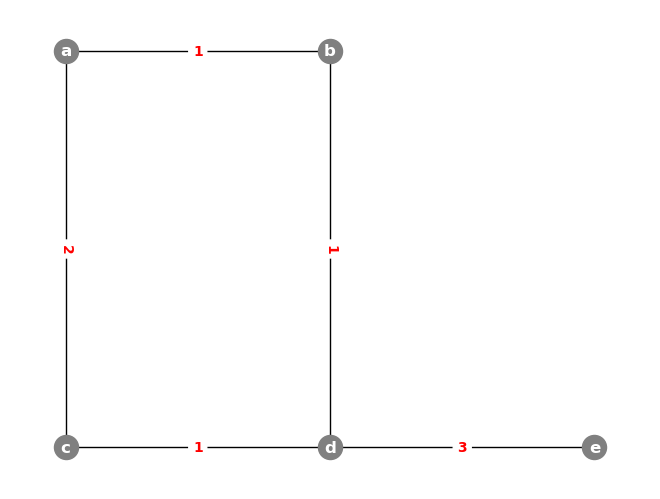

In [79]:
nx.draw(G, 
        pos=positions, 
        with_labels=True, 
        font_weight="bold", 
        font_color="white", 
        node_color="grey"
)

nx.draw_networkx_edge_labels(
    G, 
    positions,
    edge_labels=edge_labels,
    font_color='red', 
    font_weight="bold",
);

### Directed graph

In [113]:
G2 = nx.MultiDiGraph()